In [2]:
import torchvision
dataset = torchvision.datasets.OxfordIIITPet(root='./data/pet_data', download=True)
print("Oxford Pet 数据集下载解压完毕！")

100%|██████████| 792M/792M [00:03<00:00, 243MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 122MB/s] 


Oxford Pet 数据集下载解压完毕！


In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2
from torchvision import tv_tensors

# 导入自定义模型组件
import my_vit
from models_seg import ViTSegmentation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cpu


In [4]:
# 1. 模型权重配置
CHECKPOINT_PATHS = {
    'Random': './models/pet_seg_random/checkpoint-best.pth',
    'Attn': './models/pet_seg_attn/checkpoint-best.pth',
    'Edge': './models/pet_seg_edge/checkpoint-best.pth'
}

# 2. 批量测试图片列表
IMAGE_NAMES = [
    'Abyssinian_1',  
    'Maine_Coon_103',
    'pug_7',
    'beagle_1',
    'Abyssinian_36'
]

# 3. 基础路径与参数
IMG_DIR_BASE  = './data/pet_data/oxford-iiit-pet/images/'
MASK_DIR_BASE = './data/pet_data/oxford-iiit-pet/annotations/trimaps/'
SAVE_PATH     = './output/batch_seg_vis_result.png'

IMG_SIZE    = 224
PATCH_SIZE  = 16
ENCODER_DIM = 768
ENCODER_DEPTH = 16
ENCODER_HEADS = 16
NUM_CLASSES = 3

In [5]:
# ImageNet 归一化参数
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def inverse_imagenet_normalize(t):
    """还原图像到 [0,1] 用于显示"""
    mean = IMAGENET_MEAN.to(t.device)
    std  = IMAGENET_STD.to(t.device)
    return (t * std + mean).clamp(0, 1)

def decode_segmap(mask_tensor):
    """
    将 [H, W] 的类别索引矩阵 (0, 1, 2) 转化为 RGB 图像。
    0: 宠物主体 (深红)
    1: 背景 (深绿)
    2: 边缘过渡 (深蓝)
    """
    mask_np = mask_tensor.cpu().numpy()
    
    # 定义类别到颜色的映射表, 低饱和度配色
    cmap = np.array([
        [200, 100, 100],  # 0: 宠物主体 (柔和红)
        [0, 0, 0],        # 1: 背景 (纯黑)
        [135, 206, 235]   # 2: 边缘毛发 (浅湖蓝)
    ], dtype=np.uint8)
    
    # 利用 Numpy 的高级索引，瞬间完成映射
    rgb_mask = cmap[mask_np]
    return rgb_mask

In [6]:
def load_seg_model(ckpt_path):
    backbone = my_vit.MyVit(
        img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=ENCODER_DIM,
        depth=ENCODER_DEPTH, num_heads=ENCODER_HEADS, pool='mean', num_classes=NUM_CLASSES
    )
    model = ViTSegmentation(backbone=backbone, embed_dim=ENCODER_DIM, num_classes=NUM_CLASSES)
    
    if os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        state_dict = checkpoint['model']
        if any(k.startswith('module.') for k in state_dict.keys()):
            state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        model.load_state_dict(state_dict, strict=True)
    else:
        print(f"找不到权重文件 {ckpt_path}，使用随机初始化权重占位！")
        
    model.to(device)
    model.eval()
    return model

# 将所有配置的模型一次性加载进字典
loaded_models = {}
for model_name, ckpt_path in CHECKPOINT_PATHS.items():
    print(f"正在加载模型: {model_name} ...")
    loaded_models[model_name] = load_seg_model(ckpt_path)

print("所有模型加载完毕，准备批量推理！")

🚀 正在加载模型: Random ...
🚀 正在加载模型: Attn ...
🚀 正在加载模型: Edge ...
✅ 所有模型加载完毕，准备批量推理！


开始批量推理，共 5 张图片...


/tmp/ipykernel_16/409866752.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


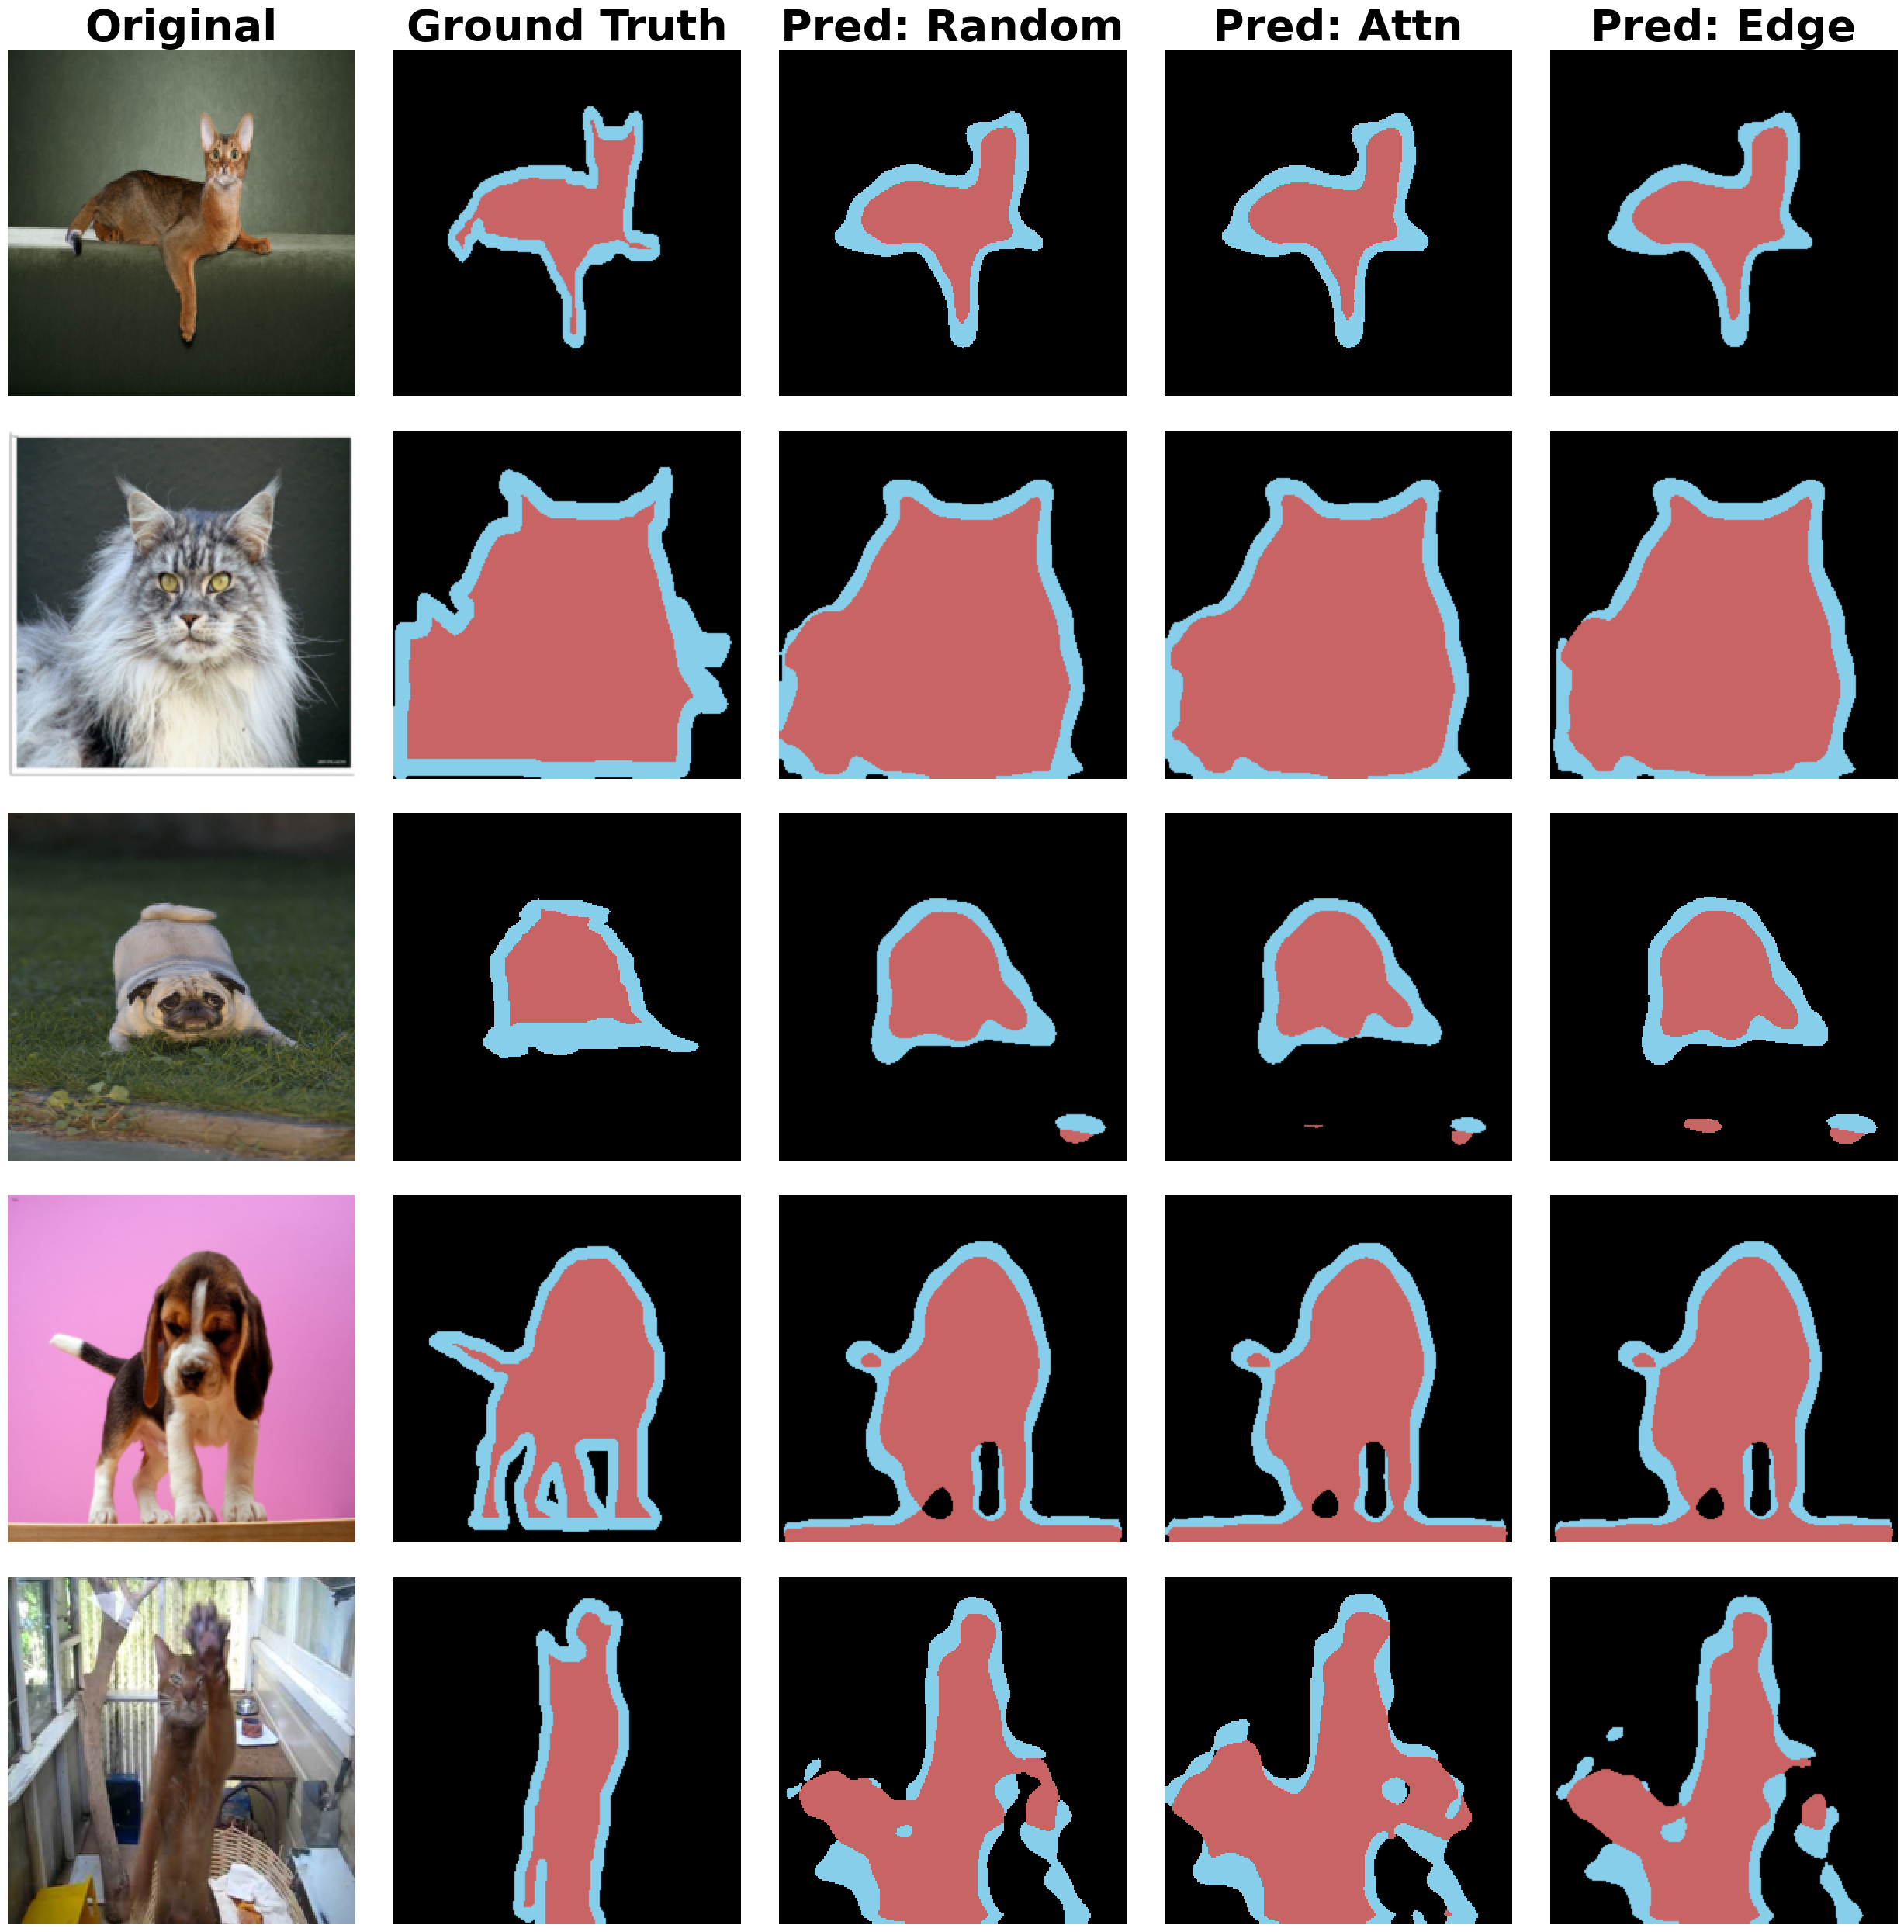

🎉 批量图表生成完毕！完美保存至: /kaggle/working/output/batch_seg_vis_result.png


In [7]:
val_transforms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

num_images = len(IMAGE_NAMES)
num_models = len(loaded_models)
total_cols = 2 + num_models # 原图 + GT + N个模型

# 动态生成子图网格 (行=图片数, 列=任务数)
fig, axes = plt.subplots(num_images, total_cols, figsize=(5 * total_cols, 5 * num_images))

# 兼容：如果只有一张图或单列，强制将其转为 2D 数组格式以防索引报错
if num_images == 1: axes = np.expand_dims(axes, axis=0)
if total_cols == 1: axes = np.expand_dims(axes, axis=1)

print(f"开始批量推理，共 {num_images} 张图片...")

with torch.no_grad():
    for row_idx, img_name in enumerate(IMAGE_NAMES):
        # 1. 拼装每张图的独立路径
        img_path = os.path.join(IMG_DIR_BASE, f"{img_name}.jpg")
        mask_path = os.path.join(MASK_DIR_BASE, f"{img_name}.png")
        
        # 2. 读取与预处理
        img_pil = Image.open(img_path).convert('RGB')
        mask_pil = Image.open(mask_path).convert('L')
        mask_v2 = tv_tensors.Mask(mask_pil)
        
        img_tensor, mask_tensor = val_transforms(img_pil, mask_v2)
        mask_tensor = mask_tensor.to(torch.long) - 1
        if mask_tensor.dim() == 3: mask_tensor = mask_tensor.squeeze(0)
        
        x = img_tensor.unsqueeze(0).to(device)
        gt_mask = mask_tensor.to(device)
        
        # 3. 准备最左侧两列的参考图
        original_display = inverse_imagenet_normalize(img_tensor)
        original_np = original_display.cpu().permute(1, 2, 0).numpy()
        gt_rgb = decode_segmap(gt_mask)
        
        # 绘制原图
        axes[row_idx, 0].imshow(original_np)
        axes[row_idx, 0].axis('off')
        if row_idx == 0: axes[row_idx, 0].set_title('Original', fontsize=40, fontweight='bold')
            
        # 绘制 GT
        axes[row_idx, 1].imshow(gt_rgb)
        axes[row_idx, 1].axis('off')
        if row_idx == 0: axes[row_idx, 1].set_title('Ground Truth', fontsize=40, fontweight='bold')
        
        # 4. 依次把图片喂给不同的模型并绘制结果
        for col_idx, (model_name, model) in enumerate(loaded_models.items()):
            with torch.cuda.amp.autocast():
                output = model(x)
            
            pred_mask = output.argmax(dim=1).squeeze(0)
            pred_rgb = decode_segmap(pred_mask)
            
            ax = axes[row_idx, 2 + col_idx]
            ax.imshow(pred_rgb)
            ax.axis('off')
            # 仅在第一行打标题，保持排版清爽
            if row_idx == 0: 
                ax.set_title(f'Pred: {model_name}', fontsize=40, fontweight='bold')

# 第一步：先让系统自动紧凑排版
plt.tight_layout()

# 第二步：强行拉开行与行之间的垂直间距（制造白色分割线）
# hspace: 控制上下行间距
# wspace: 控制左右列间距
plt.subplots_adjust(hspace=0.1, wspace=0.03)

# 创建保存目录并保存
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f'批量图表生成完毕！完美保存至: {SAVE_PATH}')